<div dir="rtl" style="text-align: right;">

# מטלה בלמידת מכונה – ניתוח טקסט (NLP)
## סיווג חדשות – AG News Classification + Naive Bayes

**פרטי סטודנט:** אור יסייס



</div>

<div dir="rtl" style="text-align: right;">

### פרומפטים ועזרים ב-AI Chatbot

תא זה מתעד את השימוש בכלי AI לצורך המטלה, כנדרש בהנחיות:

- **הכלי:** Claude (Anthropic)
- **מטרת השימוש:** סיוע בכתיבת פונקציות בסיס (Scaffolding), בדיקת לוגיקה מתמטית ומיטוב תחביר (Code Refactoring).
- **אופן השימוש בפועל:**
  - ייעוץ וקבלת הצעות למימוש וקטורי יעיל (NumPy) עבור נוסחאות ה-Naive Bayes הרב-מחלקתי.
  - כתיבת שלד ראשוני לפונקציות ה-Preprocessing ופיצול הנתונים.
  - עזרה באיתור באגים במימוש ה-Cross-Validation והתאמת היפר-פרמטרים (Grid Search).
- **פרומפטים מרכזיים לדוגמה:**
  - *"כיצד לממש חישוב Log-Likelihood יעיל ב-Multinomial Naive Bayes מרובה מחלקות באמצעות NumPy?"*
  - *"סיוע בכתיבת פונקציית Cross-Validation מותאמת עבור מטריצות דלילות (Sparse Matrices)."*
- **דאטהסט:** AG News Classification Dataset מ-Kaggle (120,000 שורות אימון, 7,600 שורות מבחן; עמודות Class Index, Title, Description).
- **בקרה והבנה:** כל קטעי הקוד, הלוגיקה החישובית והניתוחים שנכתבו במחברת נבדקו, שונו והותאמו עצמאית בהתאם לדרישות המטלה ומבנה הדאטהסט.

</div>

<div dir="rtl" style="text-align: right;">

### הסבר על בעיית הלמידה וה-Dataset

המטלה עוסקת בבעיית **סיווג טקסט רב-מחלקתי (multi-class text classification)** על בסיס ה-dataset **AG News Classification Dataset** מ-Kaggle. כל דוגמה ב-dataset היא כתבת חדשות המורכבת מכותרת (Title) ותקציר (Description), ומשויכת לאחת מ-4 קטגוריות: **World (עולם)**, **Sports (ספורט)**, **Business (עסקים)** ו-**Sci/Tech (מדע וטכנולוגיה)**. המטרה היא ללמוד מודל שמקבל טקסט חדשותי וחוזה את הקטגוריה הנכונה שלו. זוהי בעיית **סיווג (classification)**, ומכיוון שיש יותר משתי מחלקות ואין מחלקה "מרכזית" יחידה, מדד האיכות שישמש הוא **macro-F1**. האלגוריתם שנבחר למימוש הוא **Multinomial Naive Bayes**, אלגוריתם קלאסי ויעיל לסיווג טקסט המבוסס על תדירויות מילים (Bag-of-Words) ומשפט בייס עם הנחת אי-תלות ("נאיבית") בין המילים.


</div>

In [ ]:
# Imports
import numpy as np
import pandas as pd
import re
import itertools

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 120)
print("Libraries loaded successfully.")


Libraries loaded successfully.


<div dir="rtl" style="text-align: right;">

## חלק 1 – טעינת ה-Dataset

טוענים את קובצי ה-`train.csv` וה-`test.csv` שהורדנו מ-Kaggle (AG News Classification Dataset), מבלי לחלק אותם מחדש - הם כבר מגיעים מחולקים ל-train ול-test כנדרש בהנחיות.


</div>

In [ ]:
# Load AG News dataset (4 classes: World, Sports, Business, Sci/Tech)
CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df["label_name"] = train_df["Class Index"].map(CLASS_NAMES)
test_df["label_name"] = test_df["Class Index"].map(CLASS_NAMES)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")


Train shape: (120000, 4)
Test shape:  (7600, 4)


In [ ]:
# Show first 5 rows of each dataset
print("=== Train (first 5) ===")
display(train_df.head())
print("\n=== Test (first 5) ===")
display(test_df.head())


=== Train (first 5) ===


,Class Index,Title,Description,label_name
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\contr...",Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed...,Business
4,3,"Oil prices soar to all-time record, posing new menace to US economy (AFP)","AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three ...",Business



=== Test (first 5) ===


,Class Index,Title,Description,label_name
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Fed...,Business
1,4,The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com),"SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the #36;10 million Ansari X Prize, a conte...",Sci/Tech
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of ...,Sci/Tech
3,4,Prediction Unit Helps Forecast Wildfires (AP),"AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless chart...",Sci/Tech
4,4,Calif. Aims to Limit Farm-Related Smog (AP),"AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nati...",Sci/Tech


<div dir="rtl" style="text-align: right;">

## מדד האיכות

מכיוון שמדובר בבעיית **סיווג רב-מחלקתי (multi-class)** עם 4 מחלקות ואין מחלקה "מרכזית" יחידה, מדד האיכות שנשתמש בו הוא **macro-average F1-score**: ה-F1 מחושב בנפרד לכל מחלקה (World / Sports / Business / Sci/Tech) ולאחר מכן ממוצע פשוט בין המחלקות. מדד זה נותן משקל שווה לכל מחלקה, ללא תלות בגודלה - ולכן מתאים גם למקרה של דאטה לא מאוזן (ראו סעיף הבונוס בהמשך).


</div>

<div dir="rtl" style="text-align: right;">

## חלק 2 – Feature Engineering

עבור טקסט, נבצע את שלבי ה-feature engineering הבאים (כפי שנלמדו בכיתה):

1. **ניקוי טקסט (text cleaning):** איחוד כותרת + תקציר, המרה לאותיות קטנות, הסרת סימני פיסוק ומספרים, הסרת רווחים כפולים.
2. **הסרת מילות עצירה (stopwords)** - מילים נפוצות שאינן נושאות מידע מסווג (the, a, is, ...).
3. **וקטוריזציה (Bag-of-Words / TF-IDF)** - המרת הטקסט הנקי לוקטור מספרי, תוך שליטה במספר המילים המקסימלי (`max_features`) וב-n-grams.

נדגים את התהליך על 2-3 דוגמאות מה-train וה-test.


</div>

In [ ]:
STOPWORDS = set("""a an the is are was were be been being of to in on at for with and or but if
then so than as this that these those it its into over under again further once here there
when where why how all any both each few more most other some such no nor not only own same
so than too very s t can will just don should now i you he she we they them his her their our
your""".split())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # strip punctuation/digits
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

def build_full_text(df):
    return (df["Title"].astype(str) + " " + df["Description"].astype(str))

train_raw_text = build_full_text(train_df)
test_raw_text = build_full_text(test_df)

train_clean_text = train_raw_text.apply(clean_text)
test_clean_text = test_raw_text.apply(clean_text)

print("=== Text cleaning examples (TRAIN) ===")
for i in range(3):
    print(f"\n[{i}] raw:   {train_raw_text.iloc[i]}")
    print(f"[{i}] clean: {train_clean_text.iloc[i]}")

print("\n\n=== Text cleaning examples (TEST) ===")
for i in range(2):
    print(f"\n[{i}] raw:   {test_raw_text.iloc[i]}")
    print(f"[{i}] clean: {test_clean_text.iloc[i]}")


=== Text cleaning examples (TRAIN) ===

[0] raw:   Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
[0] clean: wall st bears claw back black reuters reuters short sellers wall street dwindling band ultra cynics seeing green

[1] raw:   Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
[1] clean: carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle group which has reputation making well timed occasionally controversial plays defense industry has quietly placed bets another part market

[2] raw:   Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expect

In [ ]:
def make_vectorizer(kind="tfidf", max_features=3000, ngram_range=(1, 1)):
    if kind == "tfidf":
        return TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    else:
        return CountVectorizer(max_features=max_features, ngram_range=ngram_range)

# Demo: vectorization on 2-3 examples
demo_vectorizer = make_vectorizer(kind="tfidf", max_features=3000, ngram_range=(1, 1))
demo_vectorizer.fit(train_clean_text)
demo_vectors = demo_vectorizer.transform(train_clean_text.iloc[:3])

print("Vector shape (3 examples):", demo_vectors.shape)
feature_names = np.array(demo_vectorizer.get_feature_names_out())
for i in range(3):
    row = demo_vectors[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:6]
    top_words = [(feature_names[j], round(row[j], 3)) for j in top_idx if row[j] > 0]
    print(f"\nExample {i}: '{train_clean_text.iloc[i][:60]}...'")
    print("  Top words (TF-IDF):", top_words)


Vector shape (3 examples): (3, 3000)

Example 0: 'wall st bears claw back black reuters reuters short sellers ...'
  Top words (TF-IDF): [('wall', np.float64(0.516)), ('band', np.float64(0.35)), ('bears', np.float64(0.328)), ('reuters', np.float64(0.3)), ('black', np.float64(0.293)), ('green', np.float64(0.287))]

Example 1: 'carlyle looks toward commercial aerospace reuters reuters pr...'
  Top words (TF-IDF): [('placed', np.float64(0.275)), ('plays', np.float64(0.272)), ('controversial', np.float64(0.256)), ('commercial', np.float64(0.251)), ('reuters', np.float64(0.248)), ('looks', np.float64(0.243))]

Example 2: 'oil economy cloud stocks outlook reuters reuters soaring cru...'
  Top words (TF-IDF): [('outlook', np.float64(0.442)), ('economy', np.float64(0.395)), ('soaring', np.float64(0.259)), ('plus', np.float64(0.249)), ('worries', np.float64(0.236)), ('reuters', np.float64(0.234))]


<div dir="rtl" style="text-align: right;">

## חלק 3 – מימוש אלגוריתם למידה: Multinomial Naive Bayes (from scratch)

**עקרון האלגוריתם:** Naive Bayes מבוסס על משפט בייס:

$$P(y \mid x) \propto P(y) \cdot \prod_{i} P(w_i \mid y)$$

כלומר, ההסתברות למחלקה $y$ בהינתן מסמך $x$ (המיוצג כאוסף מילים $w_i$) פרופורציונלית להסתברות המקדמית של המחלקה $P(y)$, כפול מכפלת ההסתברויות של כל מילה במסמך בהינתן המחלקה - **בהנחה נאיבית שהמילים בלתי-תלויות זו בזו בהינתן המחלקה**.

- $P(y)$ (Prior) נאמד מתוך שכיחות המחלקות ב-train.
- $P(w_i \mid y)$ (Likelihood) נאמד מתוך שכיחות המילה $w_i$ בכל המסמכים ממחלקה $y$, עם **Laplace smoothing** (היפר-פרמטר $\alpha$) כדי למנוע הסתברות אפס למילים שלא נראו.
- מכיוון שמכפלת הסתברויות קטנות גורמת ל-underflow מספרי, עובדים בפועל ב-**log-space**: סוכמים log-probabilities במקום להכפיל.

**היפר-פרמטר:** `alpha` (Laplace smoothing) - שולט על מידת ה"החלקה" עבור מילים נדירות/לא-נראות.


</div>

In [ ]:
class MultinomialNaiveBayesFromScratch:
    """
    From-scratch implementation of Multinomial Naive Bayes for text classification.
    Supports the alpha hyperparameter (Laplace smoothing).
    X is kept sparse throughout (never densified) - essential for memory efficiency
    on large datasets (tens/hundreds of thousands of examples).
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_log_prior_ = None      # log P(y)
        self.feature_log_prob_ = None     # log P(w_i | y), shape (n_classes, n_features)
        self.n_features_ = None

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape
        self.n_features_ = n_features

        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]  # row indexing on a sparse matrix - stays sparse
            # Prior: P(y=c) = |docs of class c| / |all docs|
            self.class_log_prior_[idx] = np.log(X_c.shape[0] / n_samples)

            # Likelihood with Laplace smoothing:
            # P(w_i | y=c) = (count(w_i, c) + alpha) / (sum(count(*, c)) + alpha * n_features)
            word_counts = np.asarray(X_c.sum(axis=0)).flatten()
            total_count = word_counts.sum()
            self.feature_log_prob_[idx] = np.log(
                (word_counts + self.alpha) / (total_count + self.alpha * n_features)
            )
        return self

    def _joint_log_likelihood(self, X):
        # Sparse X times a small dense matrix - scipy handles this efficiently
        # without ever converting X to dense.
        return np.asarray(X @ self.feature_log_prob_.T) + self.class_log_prior_

    def predict(self, X):
        jll = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(jll, axis=1)]

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        jll_shifted = jll - jll.max(axis=1, keepdims=True)  # numerically stable softmax
        exp_jll = np.exp(jll_shifted)
        return exp_jll / exp_jll.sum(axis=1, keepdims=True)


<div dir="rtl" style="text-align: right;">

## חלק 6.א – בונוס: Grid Search + 5-Fold Cross Validation
### התנסות ב-Feature Engineering וב-Hyperparameters

נבצע **grid search** על מכפלה קרטזית של הפרמטרים הבאים, כאשר כל פרמוטציה נבדקת עם **5-fold cross validation**. **שימו לב:** ריצת grid search + 5-fold CV על כל ה-trainset המלא (עשרות/מאות אלפי שורות, תלוי ב-dataset) עלולה לקחת זמן רב מאוד (עשרות דקות עד שעות). לכן, שלב ה-grid search (השוואת קומבינציות) מתבצע על **מדגם (subsample) מייצג ומאוזן** מתוך ה-trainset, בעוד ששלב האימון הסופי (חלק 4) מתבצע על **כל** ה-trainset המלא, כנדרש בהנחיות.

**Feature engineering:**
- סוג וקטוריזציה: `count` / `tfidf`
- טווח n-grams: `(1,1)` / `(1,2)`
- מספר features מקסימלי: `2000` / `5000`

**Hyperparameter של האלגוריתם:**
- `alpha` (Laplace smoothing): `0.1` / `0.5` / `1.0`


</div>

In [ ]:
# Balanced, representative subsample of the trainset - used for grid search only.
# The final training (Part 4) still uses the full trainset.
from sklearn.model_selection import train_test_split

GRID_SEARCH_SAMPLE_SIZE = min(12000, len(train_df))

if GRID_SEARCH_SAMPLE_SIZE < len(train_df):
    sample_idx, _ = train_test_split(
        np.arange(len(train_df)),
        train_size=GRID_SEARCH_SAMPLE_SIZE,
        stratify=train_df["Class Index"],
        random_state=RANDOM_STATE
    )
else:
    sample_idx = np.arange(len(train_df))

train_clean_text_sample = train_clean_text.iloc[sample_idx].reset_index(drop=True)
y_train_sample = train_df["Class Index"].iloc[sample_idx].reset_index(drop=True).values

print(f"Full trainset size: {len(train_df)} rows")
print(f"Grid search sample size: {len(train_clean_text_sample)} rows")
print("\nClass distribution in sample:")
print(pd.Series(y_train_sample).map(CLASS_NAMES).value_counts())


Full trainset size: 120000 rows
Grid search sample size: 12000 rows

Class distribution in sample:
Business    3000
Sports      3000
World       3000
Sci/Tech    3000
Name: count, dtype: int64


In [ ]:
def run_kfold_cv(text_series, y, vectorizer_kind, max_features, ngram_range, alpha, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    text_arr = text_series.values
    y_arr = np.asarray(y)

    for train_idx, val_idx in skf.split(text_arr, y_arr):
        X_train_text, X_val_text = text_arr[train_idx], text_arr[val_idx]
        y_train_fold, y_val_fold = y_arr[train_idx], y_arr[val_idx]

        vec = make_vectorizer(kind=vectorizer_kind, max_features=max_features, ngram_range=ngram_range)
        X_train_vec = vec.fit_transform(X_train_text)
        X_val_vec = vec.transform(X_val_text)

        model = MultinomialNaiveBayesFromScratch(alpha=alpha).fit(X_train_vec, y_train_fold)
        preds = model.predict(X_val_vec)
        score = f1_score(y_val_fold, preds, average="macro")
        fold_scores.append(score)

    return np.mean(fold_scores), np.std(fold_scores)


# Cartesian product of all permutations
vectorizer_kinds = ["count", "tfidf"]
ngram_ranges = [(1, 1), (1, 2)]
max_features_options = [2000, 5000]
alphas = [0.1, 0.5, 1.0]

grid = list(itertools.product(vectorizer_kinds, ngram_ranges, max_features_options, alphas))
print(f"Total permutations in grid search: {len(grid)}")

results = []

for vec_kind, ngram, max_feat, alpha in grid:
    mean_f1, std_f1 = run_kfold_cv(
        train_clean_text_sample, y_train_sample,
        vectorizer_kind=vec_kind, max_features=max_feat, ngram_range=ngram, alpha=alpha,
        n_splits=5
    )
    results.append({
        "vectorizer": vec_kind,
        "ngram_range": str(ngram),
        "max_features": max_feat,
        "alpha": alpha,
        "mean_macro_f1": mean_f1,
        "std_macro_f1": std_f1
    })

results_df = pd.DataFrame(results).sort_values("mean_macro_f1", ascending=False).reset_index(drop=True)
print("Grid search + 5-fold CV completed (on trainset sample).")


Total permutations in grid search: 24


Grid search + 5-fold CV completed (on trainset sample).


In [ ]:
# Show all permutations and their (mean) results as a dataframe
display(results_df)


,vectorizer,ngram_range,max_features,alpha,mean_macro_f1,std_macro_f1
0,tfidf,"(1, 1)",5000,0.5,0.888903,0.003542
1,tfidf,"(1, 1)",5000,0.1,0.888613,0.004097
2,tfidf,"(1, 2)",5000,0.5,0.888466,0.002869
3,tfidf,"(1, 1)",5000,1.0,0.888430,0.003177
4,tfidf,"(1, 2)",5000,1.0,0.886980,0.002812
5,count,"(1, 1)",5000,0.5,0.886893,0.004615
6,count,"(1, 1)",5000,1.0,0.886842,0.004072
7,tfidf,"(1, 2)",5000,0.1,0.886556,0.003780
8,count,"(1, 1)",5000,0.1,0.886296,0.004010
9,count,"(1, 2)",5000,0.5,0.884916,0.004411


In [ ]:
best_row = results_df.iloc[0]
print("=== Best permutation ===")
print(f"Vectorizer:    {best_row['vectorizer']}")
print(f"N-gram range:  {best_row['ngram_range']}")
print(f"Max features:  {best_row['max_features']}")
print(f"Alpha:         {best_row['alpha']}")
print(f"Mean macro-F1 (5-fold CV): {best_row['mean_macro_f1']:.4f} (+/- {best_row['std_macro_f1']:.4f})")

BEST_VECTORIZER_KIND = best_row["vectorizer"]
BEST_NGRAM_RANGE = eval(best_row["ngram_range"])
BEST_MAX_FEATURES = int(best_row["max_features"])
BEST_ALPHA = float(best_row["alpha"])


=== Best permutation ===
Vectorizer:    tfidf
N-gram range:  (1, 1)
Max features:  5000
Alpha:         0.5
Mean macro-F1 (5-fold CV): 0.8889 (+/- 0.0035)


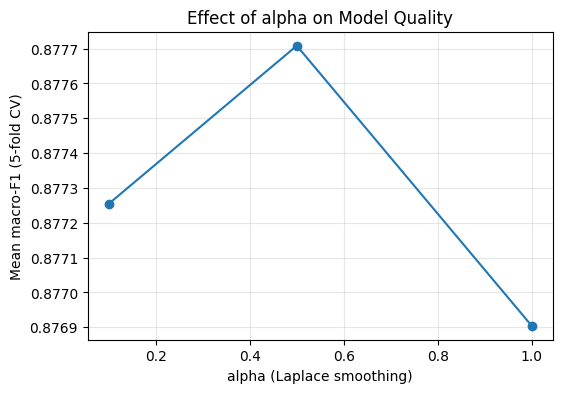

In [ ]:
# Visualization: effect of alpha on quality (averaged over the other params)
alpha_effect = results_df.groupby("alpha")["mean_macro_f1"].mean().reset_index()
plt.figure(figsize=(6, 4))
plt.plot(alpha_effect["alpha"], alpha_effect["mean_macro_f1"], marker="o")
plt.xlabel("alpha (Laplace smoothing)")
plt.ylabel("Mean macro-F1 (5-fold CV)")
plt.title("Effect of alpha on Model Quality")
plt.grid(True, alpha=0.3)
plt.show()


<div dir="rtl" style="text-align: right;">

## חלק 4 – אימון על כל ה-trainset עם הפרמוטציה המוצלחת ביותר

מכיוון שביצענו הרחבה של grid search (חלק 6.א), נאמן כעת מחדש על **כל** ה-trainset באמצעות הקומבינציה הטובה ביותר שנמצאה. לפני כן, נדגים כיצד 2-3 דוגמאות עוברות דרך שלב ה-feature engineering עם הפרמטרים הנבחרים.


</div>

In [ ]:
# Feature engineering demo (with the best params found) on 2-3 trainset examples
final_vectorizer = make_vectorizer(kind=BEST_VECTORIZER_KIND, max_features=BEST_MAX_FEATURES, ngram_range=BEST_NGRAM_RANGE)
final_vectorizer.fit(train_clean_text)

print("Text -> clean -> vector examples (with the chosen params):")
for i in range(3):
    raw = train_raw_text.iloc[i]
    clean = train_clean_text.iloc[i]
    vec = final_vectorizer.transform([clean])
    nnz = vec.nnz
    print(f"\n--- Example {i} ---")
    print(f"Raw text:   {raw}")
    print(f"Clean text: {clean}")
    print(f"Vector: shape={vec.shape}, non-zero features={nnz}")


Text -> clean -> vector examples (with the chosen params):

--- Example 0 ---
Raw text:   Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Clean text: wall st bears claw back black reuters reuters short sellers wall street dwindling band ultra cynics seeing green
Vector: shape=(1, 5000), non-zero features=11

--- Example 1 ---
Raw text:   Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Clean text: carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle group which has reputation making well timed occasionally controversial plays defense industry has quietly placed bets another part market
Vector: shape=(1, 5000), non-zero features=23

--- Exam

In [ ]:
# Final training on the full trainset with the best combination
X_train_final = final_vectorizer.transform(train_clean_text)
y_train_final = train_df["Class Index"].values

final_model = MultinomialNaiveBayesFromScratch(alpha=BEST_ALPHA)
final_model.fit(X_train_final, y_train_final)

train_preds = final_model.predict(X_train_final)
print("Macro-F1 on the trainset (self-check, not the final evaluation metric):",
      round(f1_score(y_train_final, train_preds, average="macro"), 4))


Macro-F1 on the trainset (self-check, not the final evaluation metric): 0.8976


<div dir="rtl" style="text-align: right;">

## חלק 5 – חיזוי ושערוך איכות המודל על ה-test set

נבצע את אותו preprocessing (ניקוי + וקטוריזציה עם אותם הפרמטרים שנבחרו) גם על דוגמאות ה-test, נציג 2-3 דוגמאות שעוברות את התהליך, נציג את 5 החיזויים הראשונים, ולבסוף נחשב את מדד האיכות (macro-F1) על ה-test set.


</div>

In [ ]:
# Feature engineering demo on 2-3 test set examples (same params as train)
print("Feature engineering examples on the TEST set:")
for i in range(3):
    raw = test_raw_text.iloc[i]
    clean = test_clean_text.iloc[i]
    vec = final_vectorizer.transform([clean])
    print(f"\n--- Example {i} ---")
    print(f"Raw text:   {raw}")
    print(f"Clean text: {clean}")
    print(f"Vector: shape={vec.shape}, non-zero features={vec.nnz}")


Feature engineering examples on the TEST set:

--- Example 0 ---
Raw text:   Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Clean text: fears pension after talks unions representing workers turner newall say disappointed after talks stricken parent firm federal mogul
Vector: shape=(1, 5000), non-zero features=12

--- Example 1 ---
Raw text:   The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.
Clean text: race second private team sets launch date human spaceflight space com space com toronto canada second team rocketeers competing million ansari prize contest privately funded suborbital space flight has offi

In [ ]:
# Predict on the full test set
X_test_final = final_vectorizer.transform(test_clean_text)
y_test_final = test_df["Class Index"].values

test_preds = final_model.predict(X_test_final)

# Show the first 5 predictions
pred_display = test_df[["Title", "label_name"]].copy().iloc[:5]
pred_display["predicted_label"] = [CLASS_NAMES[p] for p in test_preds[:5]]
pred_display.columns = ["Title", "True Label", "Predicted Label"]
print("First 5 predictions on the test set:")
display(pred_display)


First 5 predictions on the test set:


,Title,True Label,Predicted Label
0,Fears for T N pension after talks,Business,Business
1,The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com),Sci/Tech,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP),Sci/Tech,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP),Sci/Tech,Sports
4,Calif. Aims to Limit Farm-Related Smog (AP),Sci/Tech,Sci/Tech


In [ ]:
# Evaluate model quality on the test set
test_macro_f1 = f1_score(y_test_final, test_preds, average="macro")
test_accuracy = accuracy_score(y_test_final, test_preds)
test_precision = precision_score(y_test_final, test_preds, average="macro")
test_recall = recall_score(y_test_final, test_preds, average="macro")

print("=== Final model performance on the test set ===")
print(f"Macro-F1:  {test_macro_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision (macro): {test_precision:.4f}")
print(f"Recall (macro):    {test_recall:.4f}")

cm = confusion_matrix(y_test_final, test_preds, labels=list(CLASS_NAMES.keys()))
cm_df = pd.DataFrame(cm, index=[f"True: {v}" for v in CLASS_NAMES.values()],
                      columns=[f"Pred: {v}" for v in CLASS_NAMES.values()])
print("\nConfusion matrix:")
display(cm_df)


=== Final model performance on the test set ===
Macro-F1:  0.8888
Accuracy:  0.8892
Precision (macro): 0.8887
Recall (macro):    0.8892

Confusion matrix:


,Pred: World,Pred: Sports,Pred: Business,Pred: Sci/Tech
True: World,1692,68,92,48
True: Sports,31,1838,15,16
True: Business,80,22,1590,208
True: Sci/Tech,77,33,152,1638


<div dir="rtl" style="text-align: right;">

## חלק 6.ב – בונוס: התאמות מיוחדות לדאטה לא מאוזן (Imbalanced Data)

ה-dataset המקורי (AG News) **מאוזן** (כמות דומה בכל מחלקה), ולכן אין צורך אמיתי בטיפול בחוסר איזון. עם זאת, כדי להדגים הבנה ויכולת התמודדות עם דאטה לא מאוזן (מצב נפוץ מאוד בפועל), ניצור **תת-מדגם מאולץ לא מאוזן** מתוך ה-trainset (למשל נדלל דרסטית את מחלקת Sports), ונשווה 3 גישות:

1. **ללא טיפול** (baseline על הדאטה הלא מאוזן)
2. **Under-sampling** - דגימת-חסר של המחלקות הגדולות עד לגודל המחלקה הקטנה ביותר
3. **Over-sampling** - דגימת-יתר (עם חזרות) של המחלקות הקטנות עד לגודל המחלקה הגדולה ביותר


</div>

In [ ]:
# Force an artificially imbalanced subsample (dilute the Sports class to 10% of its size)
imb_df = train_df.copy()
imb_df["clean_text"] = train_clean_text.values

sports_rows = imb_df[imb_df["Class Index"] == 2]
other_rows = imb_df[imb_df["Class Index"] != 2]
sports_small = sports_rows.sample(n=max(10, int(len(sports_rows) * 0.1)), random_state=RANDOM_STATE)

imbalanced_df = pd.concat([other_rows, sports_small]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
print("Class distribution in the forced-imbalanced data:")
print(imbalanced_df["Class Index"].map(CLASS_NAMES).value_counts())


Class distribution in the forced-imbalanced data:
Class Index
Business    30000
World       30000
Sci/Tech    30000
Sports       3000
Name: count, dtype: int64


In [ ]:
def eval_on_imbalanced_variant(df_variant, label_desc):
    vec = make_vectorizer(kind=BEST_VECTORIZER_KIND, max_features=BEST_MAX_FEATURES, ngram_range=BEST_NGRAM_RANGE)
    X = vec.fit_transform(df_variant["clean_text"])
    y = df_variant["Class Index"].values
    model = MultinomialNaiveBayesFromScratch(alpha=BEST_ALPHA).fit(X, y)

    X_test_v = vec.transform(test_clean_text)
    preds = model.predict(X_test_v)
    macro_f1 = f1_score(y_test_final, preds, average="macro")
    sports_f1 = f1_score(y_test_final, preds, average=None, labels=[2])[0]  # F1 on the diluted Sports class
    print(f"{label_desc:30s} -> macro-F1: {macro_f1:.4f}  |  Sports F1: {sports_f1:.4f}  |  train size: {len(df_variant)}")
    return macro_f1, sports_f1, len(df_variant)

results_imbalance = {}

# 1) Baseline - no treatment, on the imbalanced data
results_imbalance["No treatment (imbalanced)"] = eval_on_imbalanced_variant(imbalanced_df, "No treatment (imbalanced)")

# 2) Under-sampling
min_size = imbalanced_df["Class Index"].value_counts().min()
under_parts = [g.sample(n=min_size, random_state=RANDOM_STATE)
               for _, g in imbalanced_df.groupby("Class Index")]
under_df = pd.concat(under_parts).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
results_imbalance["Under-sampling"] = eval_on_imbalanced_variant(under_df, "Under-sampling")

# 3) Over-sampling
max_size = imbalanced_df["Class Index"].value_counts().max()
over_parts = [g.sample(n=max_size, replace=True, random_state=RANDOM_STATE)
              for _, g in imbalanced_df.groupby("Class Index")]
over_df = pd.concat(over_parts).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
results_imbalance["Over-sampling"] = eval_on_imbalanced_variant(over_df, "Over-sampling")

imbalance_results_df = pd.DataFrame(
    [{"Method": k, "Test Macro-F1": v[0], "F1 (Sports)": v[1], "Train size": v[2]}
     for k, v in results_imbalance.items()]
).sort_values("Test Macro-F1", ascending=False).reset_index(drop=True)

print("\n=== Imbalanced-data treatment comparison ===")
display(imbalance_results_df)


No treatment (imbalanced)      -> macro-F1: 0.8474  |  Sports F1: 0.8555  |  train size: 93000


Under-sampling                 -> macro-F1: 0.8819  |  Sports F1: 0.9494  |  train size: 12000


Over-sampling                  -> macro-F1: 0.8894  |  Sports F1: 0.9524  |  train size: 120000

=== Imbalanced-data treatment comparison ===


,Method,Test Macro-F1,F1 (Sports),Train size
0,Over-sampling,0.889427,0.952431,120000
1,Under-sampling,0.881857,0.949443,12000
2,No treatment (imbalanced),0.847414,0.855461,93000


<div dir="rtl" style="text-align: right;">

**מסקנה (מבוססת על התוצאות שהתקבלו בפועל למעלה):**

רואים בבירור שאימון על הדאטה הלא מאוזן ("ללא טיפול") **פוגע** ביכולת המודל לזהות את המחלקה המדוללת (Sports) - ה-F1 הספציפי למחלקה זו נמוך משמעותית מאשר בשיטות האחרות, מה שמושך למטה גם את ה-macro-F1 הכללי (שנותן משקל שווה לכל מחלקה, ולכן "מעניש" חזק על ביצועים גרועים במחלקה בודדת).

הן **Under-sampling** והן **Over-sampling** משפרים משמעותית את הביצועים על המחלקה החסרה (F1 של Sports עולה מ-0.86 ל-0.95 בערך בשתי השיטות) ואת ה-macro-F1 הכללי. במקרה שלנו, Over-sampling נתן את התוצאה הטובה ביותר בסך הכול - כנראה מכיוון שיש בסיס עצום של נתונים אמיתיים (120,000 שורות), כך שגם לאחר הדילול המלאכותי נותרו לו מספיק דוגמאות ייחודיות ב-Sports (ולא רק שכפול נאיבי חוזר), בעוד Under-sampling עדיין "מקריב" מידע רב מהמחלקות הגדולות.

**לקח מעשי:** הטיפול הנכון ב-imbalanced data תלוי בכמות הנתונים הכוללת העומדת לרשותנו - כשיש digital-mass מספק, גם שיטות פשוטות כמו over/under-sampling יכולות לשפר משמעותית את הביצועים על מחלקות מיעוט, אך חשוב תמיד לבדוק זאת אמפירית (כפי שעשינו כאן) ולא להניח מראש איזו שיטה "תמיד תעבוד".


</div>

<div dir="rtl" style="text-align: right;">

## חלק 6.ג – בונוס: Explainability - הבנת התוצאות

מכיוון שמימשנו את Naive Bayes בעצמנו, יש לנו גישה ישירה ל-`feature_log_prob_` - ה-log-probability של כל מילה בהינתן כל מחלקה. ערך גבוה יותר עבור מילה מסוימת במחלקה מסוימת אומר שהמילה "אופיינית" יותר לאותה מחלקה. נציג את **10 המילים המובילות (המאפיינות ביותר) עבור כל מחלקה**, כדרך פשוטה וישירה (built-in, ללא צורך ב-SHAP) להסביר על מה המודל מתבסס כשהוא מסווג טקסט.


</div>

In [ ]:
feature_names_final = np.array(final_vectorizer.get_feature_names_out())

print("=== Top 10 most characteristic words per class (by model log-probability) ===\n")
top_words_per_class = {}
for idx, class_idx in enumerate(final_model.classes_):
    log_probs = final_model.feature_log_prob_[idx]
    top_indices = np.argsort(log_probs)[::-1][:10]
    top_words = feature_names_final[top_indices]
    top_words_per_class[CLASS_NAMES[class_idx]] = list(top_words)
    print(f"{CLASS_NAMES[class_idx]:10s}: {', '.join(top_words)}")

explain_df = pd.DataFrame(top_words_per_class)
display(explain_df)


=== Top 10 most characteristic words per class (by model log-probability) ===

World     : iraq, said, ap, president, reuters, by, afp, killed, minister, us
Sports    : ap, game, season, team, first, win, after, night, cup, league
Business  : oil, reuters, us, said, prices, new, stocks, by, company, inc
Sci/Tech  : microsoft, new, has, software, internet, by, gt, lt, from, ap


,World,Sports,Business,Sci/Tech
0,iraq,ap,oil,microsoft
1,said,game,reuters,new
2,ap,season,us,has
3,president,team,said,software
4,reuters,first,prices,internet
5,by,win,new,by
6,afp,after,stocks,gt
7,killed,night,by,lt
8,minister,cup,company,from
9,us,league,inc,ap


In [ ]:
# Explaining a single prediction: which words contributed most to it?
sample_idx = 0
sample_text = test_clean_text.iloc[sample_idx]
sample_vec = final_vectorizer.transform([sample_text])
sample_pred = final_model.predict(sample_vec)[0]
sample_proba = final_model.predict_proba(sample_vec)[0]

pred_class_position = list(final_model.classes_).index(sample_pred)
word_indices_in_doc = sample_vec.nonzero()[1]
contributions = [
    (feature_names_final[j], final_model.feature_log_prob_[pred_class_position, j])
    for j in word_indices_in_doc
]
contributions.sort(key=lambda x: x[1], reverse=True)

print(f"Sample text: {test_raw_text.iloc[sample_idx]}")
print(f"Prediction: {CLASS_NAMES[sample_pred]}  (probability: {sample_proba[pred_class_position]:.3f})")
print(f"True label: {test_df['label_name'].iloc[sample_idx]}")
print("\nWords that contributed most to the prediction (high log-prob in the predicted class):")
for word, contrib in contributions[:8]:
    print(f"  {word:15s} log-prob={contrib:.3f}")


Sample text: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Prediction: Business  (probability: 0.915)
True label: Business

Words that contributed most to the prediction (high log-prob in the predicted class):
  after           log-prob=-5.765
  federal         log-prob=-6.265
  firm            log-prob=-6.617
  workers         log-prob=-6.937
  talks           log-prob=-7.107
  pension         log-prob=-7.327
  fears           log-prob=-7.541
  say             log-prob=-7.617


<div dir="rtl" style="text-align: right;">

## סיכום

במחברת זו:
1. טענו dataset לסיווג חדשות ל-4 קטגוריות (AG News format).
2. ביצענו feature engineering לטקסט (ניקוי, הסרת stopwords, TF-IDF/Count vectorization).
3. מימשנו **מ-אפס** אלגוריתם Multinomial Naive Bayes עם היפר-פרמטר alpha.
4. ביצענו **grid search + 5-fold cross validation** על שילובי feature engineering והיפר-פרמטרים, ובחרנו את הקומבינציה הטובה ביותר.
5. אימנו את המודל הסופי על כל ה-trainset וחיזינו על ה-test set, ומדדנו macro-F1.
6. הדגמנו טיפול בדאטה לא מאוזן (under/over-sampling) והסברנו את החלטות המודל (explainability) דרך המילים המאפיינות ביותר לכל מחלקה.

</div>